In [3]:
import pandas as pd
import numpy as np

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Machine Learning (sklearn) ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

In [5]:
# chargement du Dataset

DATASET_PATH = 'dataset_medical_final_sans_sexe.csv'

df = pd.read_csv(DATASET_PATH)

In [6]:
# aperçu rapide du dataset

df.head()

,Patient_ID,Presence_Prostate,Presence_Uterus,Region,Diagnostic_Final,Fievre,Frissons,Céphalées,Polyurie,Douleur_Lombaire,...,Polydipsie,Oedèmes,Oligurie,Vertiges,Palpitations,Masse_Mammaire,Modification_Peau_Sein,Ecoulement_Mamelon,Retraction_Mamelon,Ganglion_Aisselle
0,CMR-2000,0,1,Sud-Ouest,Diabète_Type_2,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
1,CMR-2001,0,1,Sud-Ouest,Paludisme,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CMR-2002,1,0,Nord,Insuffisance_Rénale,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
3,CMR-2003,0,1,Centre,Insuffisance_Rénale,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
4,CMR-2004,0,1,Sud-Ouest,Choléra,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


# Inspection generale

In [7]:
#types de données et valeurs non null

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Patient_ID              1498 non-null   object
 1   Presence_Prostate       1500 non-null   int64 
 2   Presence_Uterus         1500 non-null   int64 
 3   Region                  1498 non-null   object
 4   Diagnostic_Final        1500 non-null   object
 5   Fievre                  1500 non-null   int64 
 6   Frissons                1500 non-null   int64 
 7   Céphalées               1500 non-null   int64 
 8   Polyurie                1500 non-null   int64 
 9   Douleur_Lombaire        1500 non-null   int64 
 10  Jet_Urine_Faible        1500 non-null   int64 
 11  Saignement_Vaginal      1500 non-null   int64 
 12  Douleur_Pelvienne       1500 non-null   int64 
 13  Diarrhée_Aqueuse        1500 non-null   int64 
 14  Déshydratation          1500 non-null   int64 
 15  Raid

In [8]:
#valeur manquante par colonne

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
    })
print(missing_df[missing_df['Valeurs manquantes'] > 0])

            Valeurs manquantes  Pourcentage (%)
Patient_ID                   2             0.13
Region                       2             0.13


In [9]:
# Doublons
nb_doublons = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {nb_doublons}")

Nombre de lignes dupliquées : 0


# Traitement des valeurs manquantes

In [10]:
# Patient_ID et Region ont 2 valeurs manquantes chacune
# → Patient_ID : colonne identifiant, on peut reconstruire ou laisser NaN
# → Region : variable catégorielle → imputation par le mode

print("Avant imputation :")
print(df[['Patient_ID', 'Region']].isnull().sum())

# Imputation Region par le mode
mode_region = df['Region'].mode()[0]
df['Region'] = df['Region'].fillna(mode_region)

# Reconstruction Patient_ID manquants (séquence continue)
mask_id = df['Patient_ID'].isnull()
df.loc[mask_id, 'Patient_ID'] = [
    f"CMR-XXXX-{i}" for i in range(mask_id.sum())
]

print("\nAprès imputation :")
print(df[['Patient_ID', 'Region']].isnull().sum())

Avant imputation :
Patient_ID    2
Region        2
dtype: int64

Après imputation :
Patient_ID    0
Region        0
dtype: int64


# Vérification de la cohérence biologique

In [11]:
# Un patient ne peut pas avoir à la fois une prostate ET un utérus

incoherent = df[
    (df['Presence_Prostate'] == 1) & (df['Presence_Uterus'] == 1)
]
print(f"Lignes biologiquement incohérentes : {len(incoherent)}")

# Distribution prostate / utérus
print("\nDistribution anatomique :")
print(df[['Presence_Prostate', 'Presence_Uterus']].value_counts())

Lignes biologiquement incohérentes : 0

Distribution anatomique :
Presence_Prostate  Presence_Uterus
1                  0                  753
0                  1                  747
Name: count, dtype: int64


# Encodage des variables catégorielles

In [12]:
from sklearn.preprocessing import LabelEncoder

# --- Encodage de la Région (One-Hot Encoding) ---
df_encoded = pd.get_dummies(df, columns=['Region'], prefix='Region', drop_first=False)

# --- Encodage de la cible : Diagnostic_Final (Label Encoding) ---
le_diag = LabelEncoder()
df_encoded['Diagnostic_Code'] = le_diag.fit_transform(df_encoded['Diagnostic_Final'])

print("Classes encodées :")
for i, cls in enumerate(le_diag.classes_):
    print(f"  {i} → {cls}")

print(f"\nNouvelles dimensions : {df_encoded.shape}")

Classes encodées :
  0 → Cancer_Col_Uterus
  1 → Cancer_Prostate
  2 → Cancer_Sein
  3 → Choléra
  4 → Diabète_Type_2
  5 → Hypertension
  6 → Insuffisance_Rénale
  7 → Méningite
  8 → Paludisme

Nouvelles dimensions : (1500, 33)


# Définition des features (X) et de la cible (y)

In [13]:
# Colonnes à exclure de X (non-features)

cols_a_exclure = ['Patient_ID', 'Diagnostic_Final', 'Diagnostic_Code']

X = df_encoded.drop(columns=cols_a_exclure)
y = df_encoded['Diagnostic_Code']

print(f"Features (X) : {X.shape[1]} colonnes, {X.shape[0]} lignes")
print(f"Cible    (y) : {y.nunique()} classes")
print(f"\nColonnes de X :")
print(list(X.columns))

Features (X) : 30 colonnes, 1500 lignes
Cible    (y) : 9 classes

Colonnes de X :
['Presence_Prostate', 'Presence_Uterus', 'Fievre', 'Frissons', 'Céphalées', 'Polyurie', 'Douleur_Lombaire', 'Jet_Urine_Faible', 'Saignement_Vaginal', 'Douleur_Pelvienne', 'Diarrhée_Aqueuse', 'Déshydratation', 'Raideur_Nuque', 'Photophobie', 'Polydipsie', 'Oedèmes', 'Oligurie', 'Vertiges', 'Palpitations', 'Masse_Mammaire', 'Modification_Peau_Sein', 'Ecoulement_Mamelon', 'Retraction_Mamelon', 'Ganglion_Aisselle', 'Region_Centre', 'Region_Extrême-Nord', 'Region_Littoral', 'Region_Nord', 'Region_Ouest', 'Region_Sud-Ouest']


# Séparation Train / Test

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Garder les proportions de classes
)

print(f"Ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"Ensemble de test        : {X_test.shape[0]} lignes")
print(f"\nDistribution des classes dans y_train :")
print(pd.Series(y_train).map(dict(enumerate(le_diag.classes_))).value_counts())

Ensemble d'entraînement : 1200 lignes
Ensemble de test        : 300 lignes

Distribution des classes dans y_train :
Diagnostic_Code
Hypertension           157
Cancer_Prostate        151
Insuffisance_Rénale    147
Diabète_Type_2         147
Paludisme              135
Choléra                121
Cancer_Sein            120
Méningite              115
Cancer_Col_Uterus      107
Name: count, dtype: int64


# Encodage de Region → One-Hot Encoding (OHE)

In [15]:
print("Distribution de Region avant encodage :")
print(df['Region'].value_counts())
print(f"\n→ {df['Region'].nunique()} modalités : {df['Region'].unique().tolist()}")

Distribution de Region avant encodage :
Region
Extrême-Nord    266
Ouest           262
Centre          251
Nord            241
Sud-Ouest       240
Littoral        240
Name: count, dtype: int64

→ 6 modalités : ['Sud-Ouest', 'Nord', 'Centre', 'Ouest', 'Littoral', 'Extrême-Nord']


In [16]:
# One-Hot Encoding de Region
# drop_first=True pour éviter la multicolinéarité (dummy variable trap)

df_ohe = pd.get_dummies(df, columns=['Region'], prefix='Region', drop_first=True)

region_cols = [c for c in df_ohe.columns if c.startswith('Region_')]
print(f"Colonnes créées par l'OHE ({len(region_cols)}) :")
print(region_cols)
print()
print("Aperçu des colonnes Region :")
df_ohe[region_cols].head()

Colonnes créées par l'OHE (5) :
['Region_Extrême-Nord', 'Region_Littoral', 'Region_Nord', 'Region_Ouest', 'Region_Sud-Ouest']

Aperçu des colonnes Region :


,Region_Extrême-Nord,Region_Littoral,Region_Nord,Region_Ouest,Region_Sud-Ouest
0,False,False,False,False,True
1,False,False,False,False,True
2,False,False,True,False,False
3,False,False,False,False,False
4,False,False,False,False,True


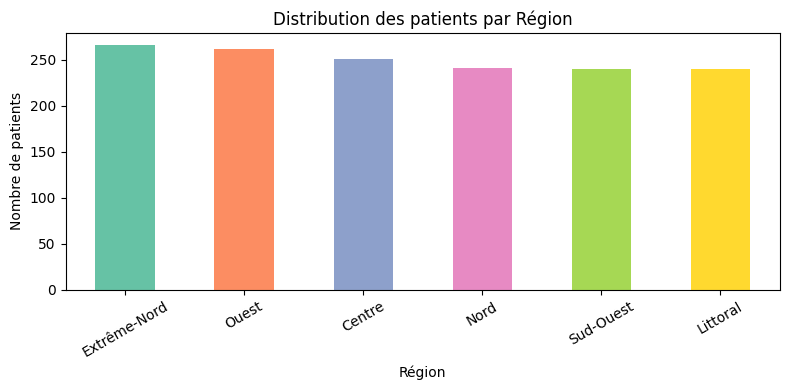

In [17]:
# Visualisation de la distribution par région
fig, ax = plt.subplots(figsize=(8, 4))
df['Region'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
ax.set_title('Distribution des patients par Région')
ax.set_xlabel('Région')
ax.set_ylabel('Nombre de patients')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Encodage de Diagnostic_Final → Label Encoding

In [18]:
from sklearn.preprocessing import LabelEncoder

print("Distribution de Diagnostic_Final avant encodage :")
print(df['Diagnostic_Final'].value_counts())

Distribution de Diagnostic_Final avant encodage :
Diagnostic_Final
Hypertension           196
Cancer_Prostate        189
Diabète_Type_2         184
Insuffisance_Rénale    183
Paludisme              169
Choléra                151
Cancer_Sein            150
Méningite              144
Cancer_Col_Uterus      134
Name: count, dtype: int64


In [19]:
le = LabelEncoder()
df_ohe['Diagnostic_Code'] = le.fit_transform(df_ohe['Diagnostic_Final'])

# Table de correspondance label ↔ code
mapping = pd.DataFrame({
    'Diagnostic'     : le.classes_,
    'Code numérique' : range(len(le.classes_))
})
print("Table de correspondance :")
print(mapping.to_string(index=False))

Table de correspondance :
         Diagnostic  Code numérique
  Cancer_Col_Uterus               0
    Cancer_Prostate               1
        Cancer_Sein               2
            Choléra               3
     Diabète_Type_2               4
       Hypertension               5
Insuffisance_Rénale               6
          Méningite               7
          Paludisme               8


C:\Users\CHRISTIAN ZEUFANG\AppData\Local\Temp\ipykernel_11492\2474683529.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Diagnostic_Final', order=order, palette='Set2', ax=ax)


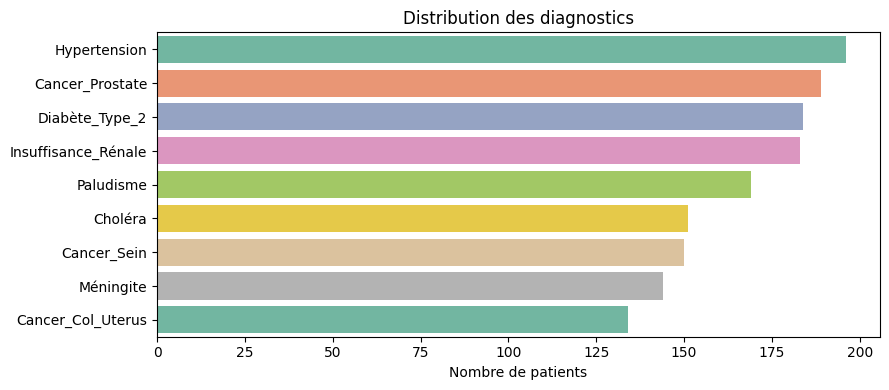

In [20]:
# Visualisation de la distribution des diagnostics
fig, ax = plt.subplots(figsize=(9, 4))
order = df['Diagnostic_Final'].value_counts().index
sns.countplot(data=df, y='Diagnostic_Final', order=order, palette='Set2', ax=ax)
ax.set_title('Distribution des diagnostics')
ax.set_xlabel('Nombre de patients')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Variables binaires : vérification (déjà encodées)

In [21]:
symptomes = [
    'Fievre', 'Frissons', 'Céphalées', 'Polyurie', 'Douleur_Lombaire',
    'Jet_Urine_Faible', 'Saignement_Vaginal', 'Douleur_Pelvienne',
    'Diarrhée_Aqueuse', 'Déshydratation', 'Raideur_Nuque', 'Photophobie',
    'Polydipsie', 'Oedèmes', 'Oligurie', 'Vertiges', 'Palpitations',
    'Masse_Mammaire', 'Modification_Peau_Sein', 'Ecoulement_Mamelon',
    'Retraction_Mamelon', 'Ganglion_Aisselle'
]

# Vérification que toutes les valeurs sont bien 0 ou 1
is_binary = df[symptomes].isin([0, 1]).all()
print(f"Colonnes binaires valides (0/1) : {is_binary.sum()} / {len(symptomes)}")

# Taux de présence moyen de chaque symptôme
prevalence = df[symptomes].mean().sort_values(ascending=False)
print("\nPrévalence des symptômes (%) :")
print((prevalence * 100).round(1).to_string())

Colonnes binaires valides (0/1) : 22 / 22

Prévalence des symptômes (%) :
Fievre                    23.9
Céphalées                 22.7
Polyurie                  22.2
Polydipsie                14.1
Oedèmes                   13.9
Frissons                  13.8
Jet_Urine_Faible          13.3
Diarrhée_Aqueuse          13.2
Saignement_Vaginal        13.0
Déshydratation            12.7
Raideur_Nuque             12.1
Oligurie                  11.5
Douleur_Pelvienne         10.9
Vertiges                   9.6
Masse_Mammaire             9.5
Douleur_Lombaire           9.4
Photophobie                9.3
Palpitations               8.8
Modification_Peau_Sein     6.5
Ganglion_Aisselle          6.5
Retraction_Mamelon         5.6
Ecoulement_Mamelon         3.9


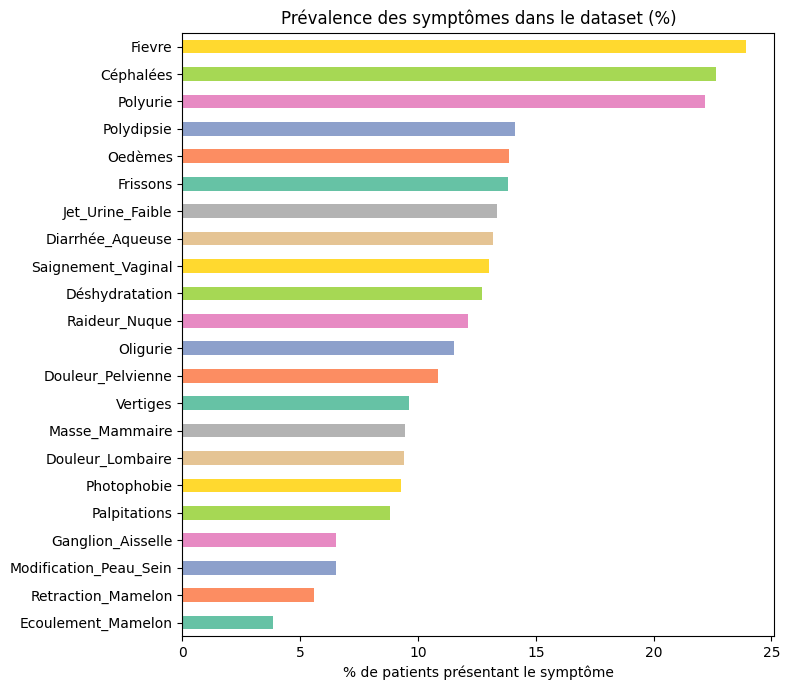

In [22]:
# Visualisation de la prévalence des symptômes
fig, ax = plt.subplots(figsize=(8, 7))
(prevalence * 100).sort_values().plot(
    kind='barh', ax=ax,
    color=sns.color_palette('Set2', len(symptomes))
)
ax.set_title('Prévalence des symptômes dans le dataset (%)')
ax.set_xlabel('% de patients présentant le symptôme')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Construction du dataset final encodé

In [23]:
# Suppression des colonnes non utilisées pour la modélisation
df_final = df_ohe.drop(columns=['Patient_ID', 'Diagnostic_Final'])

print(f"Dataset final encodé : {df_final.shape[0]} lignes × {df_final.shape[1]} colonnes")
print()
print("Colonnes du dataset encodé :")
print(list(df_final.columns))
print()
df_final.head()

Dataset final encodé : 1500 lignes × 30 colonnes

Colonnes du dataset encodé :
['Presence_Prostate', 'Presence_Uterus', 'Fievre', 'Frissons', 'Céphalées', 'Polyurie', 'Douleur_Lombaire', 'Jet_Urine_Faible', 'Saignement_Vaginal', 'Douleur_Pelvienne', 'Diarrhée_Aqueuse', 'Déshydratation', 'Raideur_Nuque', 'Photophobie', 'Polydipsie', 'Oedèmes', 'Oligurie', 'Vertiges', 'Palpitations', 'Masse_Mammaire', 'Modification_Peau_Sein', 'Ecoulement_Mamelon', 'Retraction_Mamelon', 'Ganglion_Aisselle', 'Region_Extrême-Nord', 'Region_Littoral', 'Region_Nord', 'Region_Ouest', 'Region_Sud-Ouest', 'Diagnostic_Code']



,Presence_Prostate,Presence_Uterus,Fievre,Frissons,Céphalées,Polyurie,Douleur_Lombaire,Jet_Urine_Faible,Saignement_Vaginal,Douleur_Pelvienne,...,Modification_Peau_Sein,Ecoulement_Mamelon,Retraction_Mamelon,Ganglion_Aisselle,Region_Extrême-Nord,Region_Littoral,Region_Nord,Region_Ouest,Region_Sud-Ouest,Diagnostic_Code
0,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,False,False,False,False,True,4
1,0,1,1,1,1,0,0,0,0,0,...,0,0,0,0,False,False,False,False,True,8
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,False,False,True,False,False,6
3,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,False,False,False,False,False,6
4,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,False,False,False,False,True,3


In [24]:
# Séparation X / y
X = df_final.drop(columns=['Diagnostic_Code'])
y = df_final['Diagnostic_Code']

print(f"X (features) : {X.shape[1]} colonnes × {X.shape[0]} lignes")
print(f"y (cible)    : {y.nunique()} classes → {list(le.classes_)}")

X (features) : 29 colonnes × 1500 lignes
y (cible)    : 9 classes → ['Cancer_Col_Uterus', 'Cancer_Prostate', 'Cancer_Sein', 'Choléra', 'Diabète_Type_2', 'Hypertension', 'Insuffisance_Rénale', 'Méningite', 'Paludisme']


# Séparation X / y

In [25]:
# X : features (tout sauf la cible)
# y : cible (Diagnostic_Code)

X = df_final.drop(columns=['Diagnostic_Code'])
y = df_final['Diagnostic_Code']

print(f"X (features) : {X.shape[1]} colonnes  ×  {X.shape[0]} lignes")
print(f"y (cible)    : {y.nunique()} classes")
print()
print("Colonnes de X :")
print(list(X.columns))

X (features) : 29 colonnes  ×  1500 lignes
y (cible)    : 9 classes

Colonnes de X :
['Presence_Prostate', 'Presence_Uterus', 'Fievre', 'Frissons', 'Céphalées', 'Polyurie', 'Douleur_Lombaire', 'Jet_Urine_Faible', 'Saignement_Vaginal', 'Douleur_Pelvienne', 'Diarrhée_Aqueuse', 'Déshydratation', 'Raideur_Nuque', 'Photophobie', 'Polydipsie', 'Oedèmes', 'Oligurie', 'Vertiges', 'Palpitations', 'Masse_Mammaire', 'Modification_Peau_Sein', 'Ecoulement_Mamelon', 'Retraction_Mamelon', 'Ganglion_Aisselle', 'Region_Extrême-Nord', 'Region_Littoral', 'Region_Nord', 'Region_Ouest', 'Region_Sud-Ouest']


In [26]:
# Distribution de y avant split
dist_y = pd.DataFrame({
    'Diagnostic'    : le.classes_,
    'Code'          : range(len(le.classes_)),
    'Nb patients'   : y.value_counts().sort_index().values,
    'Proportion (%)': (y.value_counts(normalize=True).sort_index().values * 100).round(1)
})
print("Distribution des classes (dataset complet) :")
print(dist_y.to_string(index=False))
print()
print(f"Ratio max/min : {y.value_counts().max()} / {y.value_counts().min()} = "
      f"{y.value_counts().max()/y.value_counts().min():.2f}")

Distribution des classes (dataset complet) :
         Diagnostic  Code  Nb patients  Proportion (%)
  Cancer_Col_Uterus     0          134             8.9
    Cancer_Prostate     1          189            12.6
        Cancer_Sein     2          150            10.0
            Choléra     3          151            10.1
     Diabète_Type_2     4          184            12.3
       Hypertension     5          196            13.1
Insuffisance_Rénale     6          183            12.2
          Méningite     7          144             9.6
          Paludisme     8          169            11.3

Ratio max/min : 196 / 134 = 1.46


# Division Train / Test (80 % / 20 %)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.20,
    random_state= 42,
    stratify    = y      # Préserve les proportions de chaque classe
)

print("=" * 45)
print(f"  Dataset total  : {len(X):>5} lignes  (100 %)")
print(f"  Train set      : {len(X_train):>5} lignes  ( 80 %)")
print(f"  Test  set      : {len(X_test):>5} lignes  ( 20 %)")
print("=" * 45)
print(f"  Features       : {X_train.shape[1]} colonnes")
print(f"  Seed (reprod.) : 42")
print(f"  Stratifié      : Oui")
print("=" * 45)

  Dataset total  :  1500 lignes  (100 %)
  Train set      :  1200 lignes  ( 80 %)
  Test  set      :   300 lignes  ( 20 %)
  Features       : 29 colonnes
  Seed (reprod.) : 42
  Stratifié      : Oui


# Vérification de la stratification

In [28]:
# Tableau comparatif Train / Test / Total
strat_check = pd.DataFrame({
    'Diagnostic'  : le.classes_,
    'Total'       : y.value_counts().sort_index().values,
    'Train'       : y_train.value_counts().sort_index().values,
    'Test'        : y_test.value_counts().sort_index().values,
    'Train %'     : (y_train.value_counts(normalize=True).sort_index().values * 100).round(1),
    'Test %'      : (y_test.value_counts(normalize=True).sort_index().values * 100).round(1),
})

print("Vérification de la stratification :")
print(strat_check.to_string(index=False))
print()
print("→ Les proportions Train % ≈ Test % confirment que la stratification est correcte")

Vérification de la stratification :
         Diagnostic  Total  Train  Test  Train %  Test %
  Cancer_Col_Uterus    134    107    27      8.9     9.0
    Cancer_Prostate    189    151    38     12.6    12.7
        Cancer_Sein    150    120    30     10.0    10.0
            Choléra    151    121    30     10.1    10.0
     Diabète_Type_2    184    147    37     12.2    12.3
       Hypertension    196    157    39     13.1    13.0
Insuffisance_Rénale    183    147    36     12.2    12.0
          Méningite    144    115    29      9.6     9.7
          Paludisme    169    135    34     11.2    11.3

→ Les proportions Train % ≈ Test % confirment que la stratification est correcte


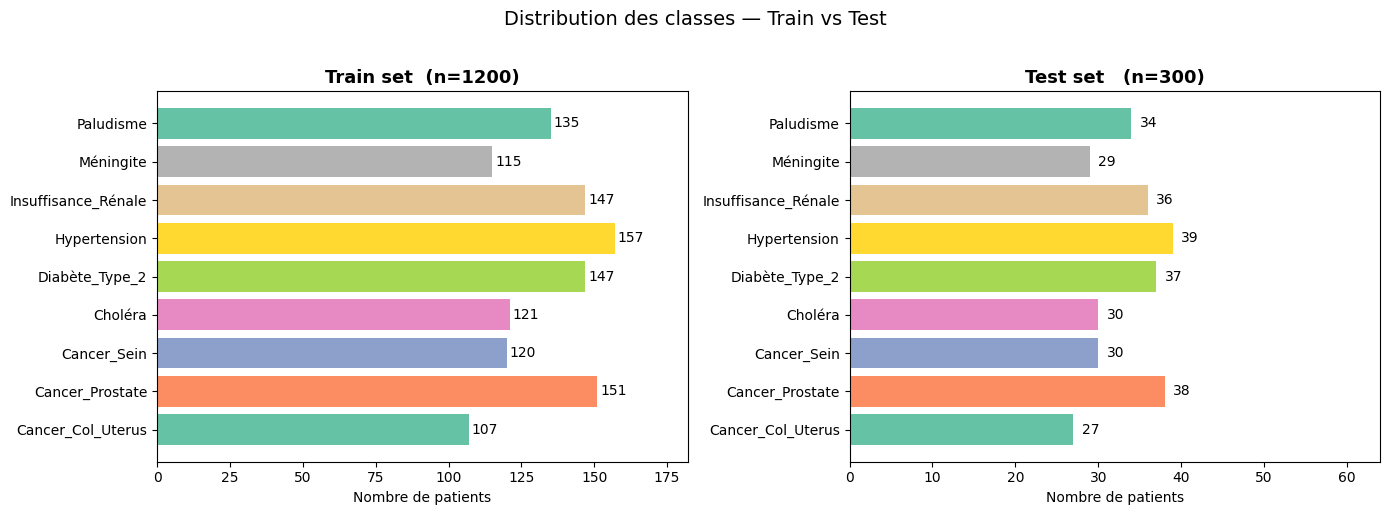

In [29]:
# Visualisation Train / Test par classe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

diag_labels = le.classes_
palette     = sns.color_palette('Set2', len(diag_labels))

for ax, (counts, title) in zip(axes, [
    (y_train.value_counts().sort_index(), f'Train set  (n={len(y_train)})'),
    (y_test.value_counts().sort_index(),  f'Test set   (n={len(y_test)})')
]):
    bars = ax.barh(diag_labels, counts.values, color=palette)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Nombre de patients')
    ax.set_xlim(0, counts.max() + 25)

plt.suptitle('Distribution des classes — Train vs Test', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

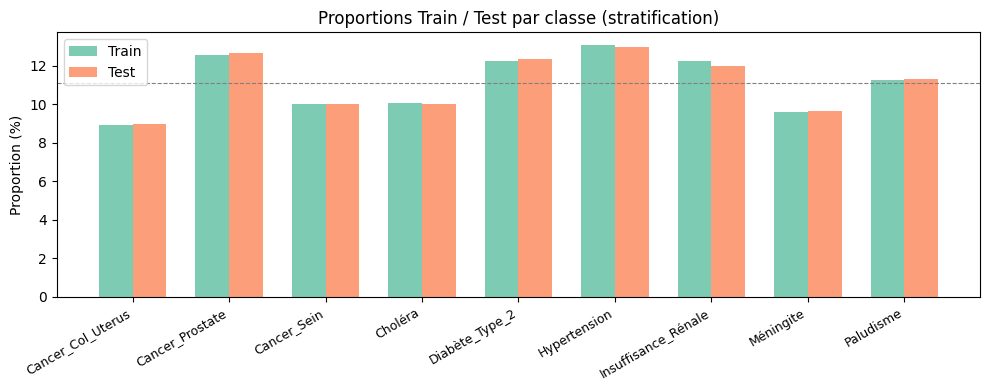

In [30]:
# Visualisation proportions comparées (barres empilées)
fig, ax = plt.subplots(figsize=(10, 4))

train_pct = y_train.value_counts(normalize=True).sort_index() * 100
test_pct  = y_test.value_counts(normalize=True).sort_index() * 100

x = np.arange(len(diag_labels))
width = 0.35

ax.bar(x - width/2, train_pct.values, width, label='Train', color=palette[0], alpha=0.85)
ax.bar(x + width/2, test_pct.values,  width, label='Test',  color=palette[1], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(diag_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Proportion (%)')
ax.set_title('Proportions Train / Test par classe (stratification)')
ax.legend()
ax.axhline(100/len(diag_labels), color='gray', linestyle='--',
           linewidth=0.8, label='Proportion idéale')
plt.tight_layout()
plt.show()

# MODÈLE 1 — Random Forest Classifier

# Entraînement Random Forest

In [31]:
rf_model = RandomForestClassifier(
    n_estimators  = 100,       # Nombre d'arbres
    max_depth     = None,      # Arbres profonds (pas de limite)
    min_samples_split = 2,     # Min échantillons pour splitter un nœud
    min_samples_leaf  = 1,     # Min échantillons dans une feuille
    max_features  = 'sqrt',    # √(nb_features) features candidates par split
    bootstrap     = True,      # Échantillonnage avec remise
    class_weight  = 'balanced',# Pondération automatique des classes
    random_state  = 42,
    n_jobs        = -1         # Utiliser tous les cœurs CPU
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)

print(f"  Random Forest entraîné sur {len(X_train)} échantillons")
print(f"   Accuracy sur le Test set : {acc_rf:.4f}  ({acc_rf*100:.2f} %)")

  Random Forest entraîné sur 1200 échantillons
   Accuracy sur le Test set : 0.9633  (96.33 %)


# Rapport de classification — Random Forest

In [32]:
CLASS_NAMES = list(le.classes_)
print(f" chargé — Train: {len(X_train)} | Test: {len(X_test)} | Classes: {len(CLASS_NAMES)}")

print("Rapport de classification — Random Forest")
print("=" * 62)
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))

 chargé — Train: 1200 | Test: 300 | Classes: 9
Rapport de classification — Random Forest
                     precision    recall  f1-score   support

  Cancer_Col_Uterus       0.96      1.00      0.98        27
    Cancer_Prostate       0.93      1.00      0.96        38
        Cancer_Sein       1.00      1.00      1.00        30
            Choléra       1.00      0.93      0.97        30
     Diabète_Type_2       0.95      0.95      0.95        37
       Hypertension       0.92      0.92      0.92        39
Insuffisance_Rénale       1.00      0.97      0.99        36
          Méningite       0.96      0.93      0.95        29
          Paludisme       0.97      0.97      0.97        34

           accuracy                           0.96       300
          macro avg       0.97      0.96      0.96       300
       weighted avg       0.96      0.96      0.96       300



# Matrice de confusion — Random Forest

 Train: 1200 | Test: 300 | Classes: 9


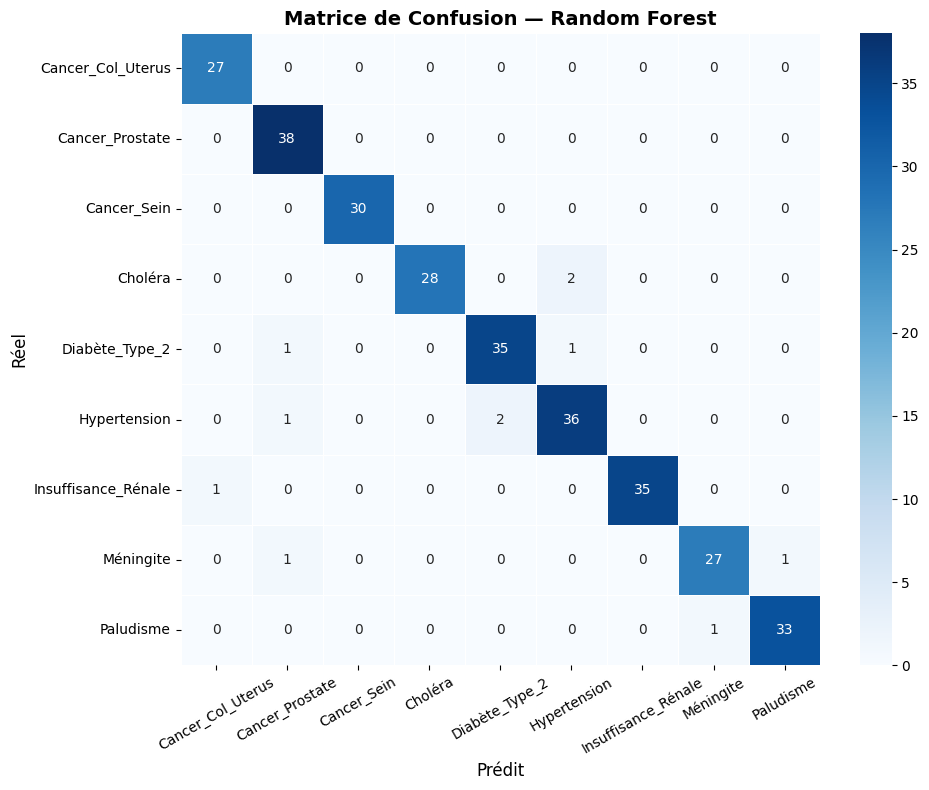

In [33]:
CLASS_NAMES = list(le.classes_)
print(f" Train: {len(X_train)} | Test: {len(X_test)} | Classes: {len(CLASS_NAMES)}")

cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_title('Matrice de Confusion — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédit',  fontsize=12)
ax.set_ylabel('Réel',    fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# Validation croisée — Random Forest

In [34]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf  = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print("Validation croisée — Random Forest (5 folds)")
print("-" * 45)
for i, score in enumerate(cv_rf, 1):
    print(f"  Fold {i} :  {score:.4f}")
print("-" * 45)
print(f"  Moyenne : {cv_rf.mean():.4f}  ±  {cv_rf.std():.4f}")
print(f"  Min     : {cv_rf.min():.4f}")
print(f"  Max     : {cv_rf.max():.4f}")

Validation croisée — Random Forest (5 folds)
---------------------------------------------
  Fold 1 :  0.9567
  Fold 2 :  0.9533
  Fold 3 :  0.9733
  Fold 4 :  0.9667
  Fold 5 :  0.9533
---------------------------------------------
  Moyenne : 0.9607  ±  0.0080
  Min     : 0.9533
  Max     : 0.9733


# Importance des features — Random Forest

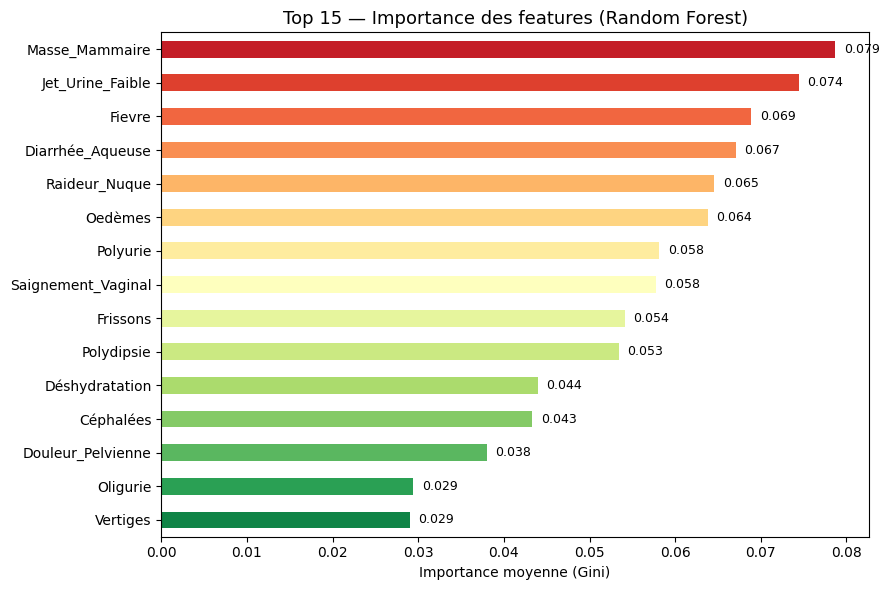


Top 10 features :
  Masse_Mammaire                 0.0787
  Jet_Urine_Faible               0.0744
  Fievre                         0.0689
  Diarrhée_Aqueuse               0.0671
  Raideur_Nuque                  0.0646
  Oedèmes                        0.0638
  Polyurie                       0.0581
  Saignement_Vaginal             0.0577
  Frissons                       0.0541
  Polydipsie                     0.0534


In [35]:
importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

# Top 15
top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('RdYlGn', 15)[::-1]
top15.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 15 — Importance des features (Random Forest)', fontsize=13)
ax.set_xlabel('Importance moyenne (Gini)')
for i, (val, name) in enumerate(zip(top15.sort_values().values, top15.sort_values().index)):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
for feat, imp in importances.head(10).items():
    print(f"  {feat:<30} {imp:.4f}")

# MODÈLE 2 — XGBoost (Gradient Boosting)

# Entraînement XGBoost (GradientBoosting)

In [36]:
xgb_model = GradientBoostingClassifier(
    n_estimators   = 100,    # Nombre de boosting rounds
    learning_rate  = 0.1,    # Taux d'apprentissage (shrinkage)
    max_depth      = 5,      # Profondeur max de chaque arbre
    min_samples_split = 2,
    min_samples_leaf  = 1,
    subsample      = 0.8,    # Fraction des échantillons par arbre
    max_features   = 'sqrt', # Fraction des features par split
    random_state   = 42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
acc_xgb    = accuracy_score(y_test, y_pred_xgb)

print(f" Gradient Boosting entraîné sur {len(X_train)} échantillons")
print(f"   Accuracy sur le Test set : {acc_xgb:.4f}  ({acc_xgb*100:.2f} %)")

 Gradient Boosting entraîné sur 1200 échantillons
   Accuracy sur le Test set : 0.9667  (96.67 %)


# Rapport de classification — XGBoost

In [37]:
print("Rapport de classification — Gradient Boosting (XGBoost)")
print("=" * 62)
print(classification_report(y_test, y_pred_xgb, target_names=CLASS_NAMES))

Rapport de classification — Gradient Boosting (XGBoost)
                     precision    recall  f1-score   support

  Cancer_Col_Uterus       0.96      1.00      0.98        27
    Cancer_Prostate       0.95      1.00      0.97        38
        Cancer_Sein       1.00      1.00      1.00        30
            Choléra       1.00      0.97      0.98        30
     Diabète_Type_2       0.97      0.97      0.97        37
       Hypertension       0.92      0.90      0.91        39
Insuffisance_Rénale       0.97      0.97      0.97        36
          Méningite       0.97      0.97      0.97        29
          Paludisme       0.97      0.94      0.96        34

           accuracy                           0.97       300
          macro avg       0.97      0.97      0.97       300
       weighted avg       0.97      0.97      0.97       300



# Matrice de confusion — XGBoost

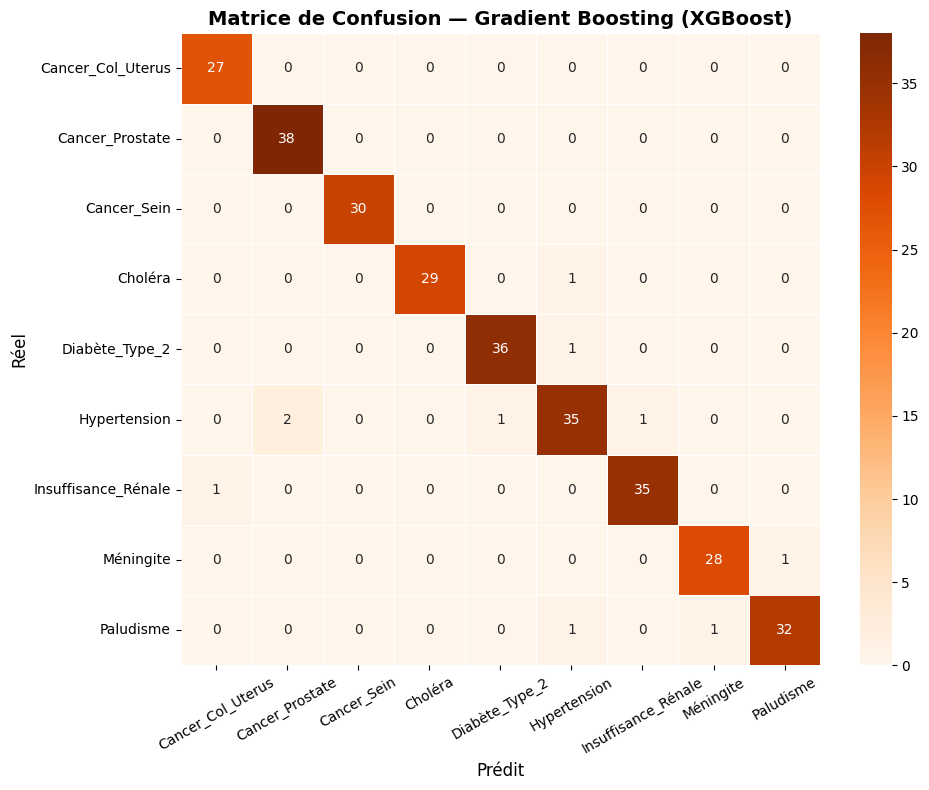

In [38]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_xgb, annot=True, fmt='d', cmap='Oranges',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_title('Matrice de Confusion — Gradient Boosting (XGBoost)', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédit',  fontsize=12)
ax.set_ylabel('Réel',    fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# Validation croisée — XGBoost

In [39]:
cv_xgb = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print("Validation croisée — Gradient Boosting / XGBoost (5 folds)")
print("-" * 50)
for i, score in enumerate(cv_xgb, 1):
    print(f"  Fold {i} :  {score:.4f}")
print("-" * 50)
print(f"  Moyenne : {cv_xgb.mean():.4f}  ±  {cv_xgb.std():.4f}")
print(f"  Min     : {cv_xgb.min():.4f}")
print(f"  Max     : {cv_xgb.max():.4f}")

Validation croisée — Gradient Boosting / XGBoost (5 folds)
--------------------------------------------------
  Fold 1 :  0.9600
  Fold 2 :  0.9500
  Fold 3 :  0.9733
  Fold 4 :  0.9733
  Fold 5 :  0.9500
--------------------------------------------------
  Moyenne : 0.9613  ±  0.0105
  Min     : 0.9500
  Max     : 0.9733


# COMPARAISON DES DEUX MODÈLES

# Tableau comparatif

In [40]:
from sklearn.metrics import f1_score, precision_score, recall_score

comparison = pd.DataFrame({
    'Modèle'          : ['Random Forest', 'Gradient Boosting (XGBoost)'],
    'Accuracy (test)' : [f'{acc_rf:.4f}', f'{acc_xgb:.4f}'],
    'F1-macro (test)' : [
        f"{f1_score(y_test, y_pred_rf,  average='macro'):.4f}",
        f"{f1_score(y_test, y_pred_xgb, average='macro'):.4f}"
    ],
    'Precision-macro' : [
        f"{precision_score(y_test, y_pred_rf,  average='macro'):.4f}",
        f"{precision_score(y_test, y_pred_xgb, average='macro'):.4f}"
    ],
    'Recall-macro'    : [
        f"{recall_score(y_test, y_pred_rf,  average='macro'):.4f}",
        f"{recall_score(y_test, y_pred_xgb, average='macro'):.4f}"
    ],
    'CV moyenne'      : [f'{cv_rf.mean():.4f}', f'{cv_xgb.mean():.4f}'],
    'CV std'          : [f'±{cv_rf.std():.4f}', f'±{cv_xgb.std():.4f}'],
})

print(comparison.to_string(index=False))

                     Modèle Accuracy (test) F1-macro (test) Precision-macro Recall-macro CV moyenne  CV std
              Random Forest          0.9633          0.9647          0.9661       0.9640     0.9607 ±0.0080
Gradient Boosting (XGBoost)          0.9667          0.9683          0.9684       0.9684     0.9613 ±0.0105


# Visualisation comparative

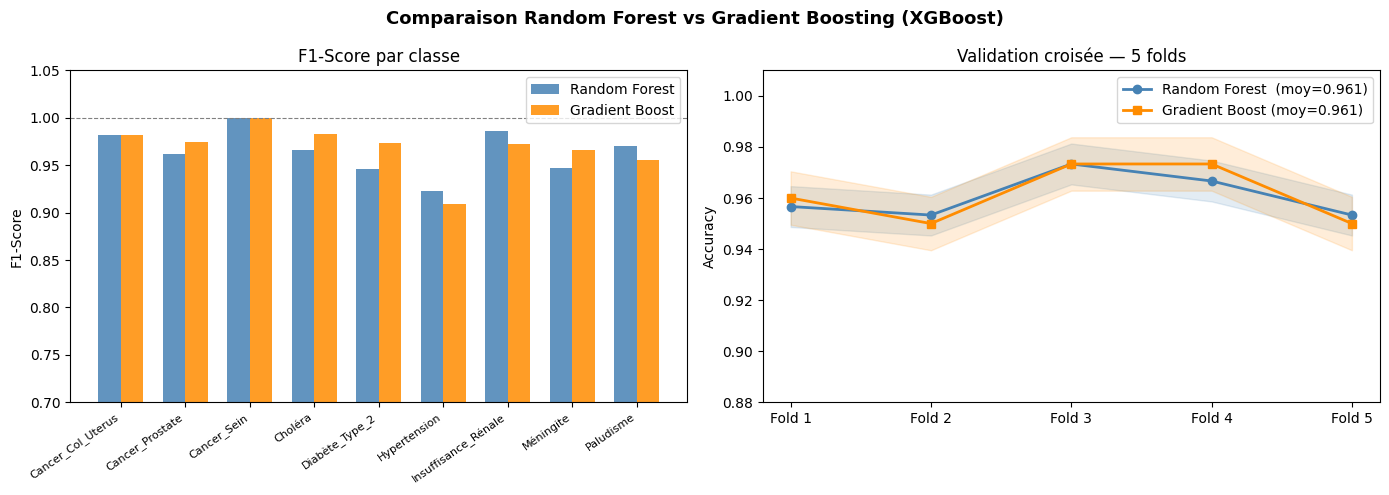

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphe 1 : Accuracy par classe ---
report_rf  = classification_report(y_test, y_pred_rf,  target_names=CLASS_NAMES, output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, target_names=CLASS_NAMES, output_dict=True)

f1_rf  = [report_rf[c]['f1-score']  for c in CLASS_NAMES]
f1_xgb = [report_xgb[c]['f1-score'] for c in CLASS_NAMES]

x    = np.arange(len(CLASS_NAMES))
w    = 0.35
ax   = axes[0]
ax.bar(x - w/2, f1_rf,  w, label='Random Forest',   color='steelblue',  alpha=0.85)
ax.bar(x + w/2, f1_xgb, w, label='Gradient Boost',  color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score par classe')
ax.legend()
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle='--')

# --- Graphe 2 : CV scores par fold ---
ax2 = axes[1]
folds = [f'Fold {i}' for i in range(1, 6)]
ax2.plot(folds, cv_rf,  'o-', color='steelblue',  label=f'Random Forest  (moy={cv_rf.mean():.3f})',  linewidth=2)
ax2.plot(folds, cv_xgb, 's-', color='darkorange', label=f'Gradient Boost (moy={cv_xgb.mean():.3f})', linewidth=2)
ax2.set_ylim(0.88, 1.01)
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation croisée — 5 folds')
ax2.legend()
ax2.fill_between(folds, cv_rf  - cv_rf.std(),  cv_rf  + cv_rf.std(),  alpha=0.15, color='steelblue')
ax2.fill_between(folds, cv_xgb - cv_xgb.std(), cv_xgb + cv_xgb.std(), alpha=0.15, color='darkorange')

plt.suptitle('Comparaison Random Forest vs Gradient Boosting (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Récapitulatif final

In [42]:
best_model = 'Random Forest' if acc_rf >= acc_xgb else 'Gradient Boosting'
best_acc   = max(acc_rf, acc_xgb)

print("=" * 55)
print("  RÉSUMÉ — ENTRAÎNEMENT DES MODÈLES")
print("=" * 55)
print(f"  Random Forest       → Accuracy : {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"  Gradient Boost(XGB) → Accuracy : {acc_xgb:.4f} ({acc_xgb*100:.2f}%)")
print()
print(f"  Meilleur modèle  : {best_model}")
print(f"    Accuracy test    : {best_acc:.4f}")
print()
print("  Top 3 features (Random Forest) :")
for feat, imp in importances.head(3).items():
    print(f"    → {feat:<28} {imp:.4f}")
print("=" * 55)
print(" Modèles entraînés — prêts pour l'évaluation.")

  RÉSUMÉ — ENTRAÎNEMENT DES MODÈLES
  Random Forest       → Accuracy : 0.9633 (96.33%)
  Gradient Boost(XGB) → Accuracy : 0.9667 (96.67%)

  Meilleur modèle  : Gradient Boosting
    Accuracy test    : 0.9667

  Top 3 features (Random Forest) :
    → Masse_Mammaire               0.0787
    → Jet_Urine_Faible             0.0744
    → Fievre                       0.0689
 Modèles entraînés — prêts pour l'évaluation.


# Test patient : prédiction par symptômes
Le patient sélectionne ses symptômes. Si le profil correspond à une maladie précise, le résultat affiche cette maladie.
Sinon, le notebook affiche les maladies les plus probables avec leurs pourcentages.
Le patient souffrira probablement de la maladie avec le pourcentage le plus élevé.


In [58]:
symptomes_test = symptomes
print("Symptômes disponibles :")
print(" - " + "\n - ".join(symptomes_test))

selected_symptoms = [
    "Fievre",
    "Frissons",
    "Céphalées",
    #"Douleur_Lombaire"
]
patient_input = pd.DataFrame([{s: int(s in selected_symptoms) for s in symptomes_test}])
print("\nSymptômes sélectionnés :", selected_symptoms)

exact_matches = df_ohe[df_ohe[symptomes_test].eq(patient_input.iloc[0]).all(axis=1)]
if len(exact_matches) > 0:
    exact_counts = exact_matches["Diagnostic_Final"].value_counts(normalize=True) * 100
    if len(exact_counts) == 1:
        print(f"\nCorrespondance exacte trouvée : {exact_counts.index[0]} ({exact_counts.iloc[0]:.1f}%)")
    else:
        print("\nCorrespondances exactes avec plusieurs diagnostics :")
        for diag, pct in exact_counts.items():
            print(f"  - {diag} : {pct:.1f}%")
        print(f"\nLe patient souffrira probablement de : {exact_counts.index[0]} ({exact_counts.iloc[0]:.1f}%)")
else:
    model = rf_model if acc_rf >= acc_xgb else xgb_model
    probs = model.predict_proba(patient_input)[0]
    order = np.argsort(probs)[::-1]
    disease_names = le.inverse_transform(model.classes_.astype(int))[order]
    top_probs = probs[order] * 100
    print("\nAucune correspondance exacte. Maladies probables :")
    for name, pct in zip(disease_names[:5], top_probs[:5]):
        print(f"  - {name} : {pct:.1f}%")
    print(f"\nLe patient souffrira probablement de : {disease_names[0]} ({top_probs[0]:.1f}%)")


Symptômes disponibles :
 - Fievre
 - Frissons
 - Céphalées
 - Polyurie
 - Douleur_Lombaire
 - Jet_Urine_Faible
 - Saignement_Vaginal
 - Douleur_Pelvienne
 - Diarrhée_Aqueuse
 - Déshydratation
 - Raideur_Nuque
 - Photophobie
 - Polydipsie
 - Oedèmes
 - Oligurie
 - Vertiges
 - Palpitations
 - Masse_Mammaire
 - Modification_Peau_Sein
 - Ecoulement_Mamelon
 - Retraction_Mamelon
 - Ganglion_Aisselle

Symptômes sélectionnés : ['Fievre', 'Frissons', 'Céphalées']

Correspondance exacte trouvée : Paludisme (100.0%)
